# 06 -- Annual Impact and Carbon

**Purpose (PROJECT.md Section 8.7):** every finding so far in this project is a single design-point (-3C) or a single 7-day event (December 2022) snapshot. This notebook takes the same three fabric states, the same archetype, and asks the question none of notebooks 01-05 answer: what does a full year actually look like -- displaced energy (MWh), household bill savings (GBP), and carbon abatement (tCO2e)? It also gives a Sledgehammer-Test (literature-grounded, not simulated) treatment of the summer dynamics winter-only snapshots miss: solar export voltage risk, and the overheating risk that a fabric-first recommendation should not omit.

**Scope boundary (PROJECT.md Section 2.2, Sledgehammer Test):** this uses 12 representative monthly mean outdoor temperatures (not a new hourly annual simulation) and researched, dated UK market/policy figures for electricity price and grid carbon intensity -- consistent with how notebooks 04 and 05 already treat economics as a researched-figure exercise, not a new bottom-up model. The method, and its stated conservative bias, live in `physics.annual_heating_electrical_kwh`.

**What this notebook is not:** a domestic hot water model, an hourly annual dispatch simulation, or a quantified overheating/voltage-rise model. All three stay in `configs/tenure_insulation_assumptions.yml`'s `omitted` list or are treated qualitatively below, not silently assumed away.

In [1]:
import sys

print("Python executable:", sys.executable)
assert "thermal-counterfactual-gb" in sys.executable, (
    "Wrong kernel selected -- pick the 'thermal-counterfactual-gb' kernel, "
    "not a default/global one. Run setup.sh first if it doesn't exist yet."
)

import numpy as np
import polars as pl
import yaml
import matplotlib.pyplot as plt
print("polars:", pl.__version__, "| numpy:", np.__version__)

Python executable: /tmp/kernelenv/thermal-counterfactual-gb/bin/python3


polars: 1.43.2 | numpy: 2.2.6


## 1. Load assumptions and Notebook 01/03 outputs

Per-state H comes from `notebooks/01`'s already-verified geometry and envelope states (recomputed here directly from config, the same way `notebooks/03`'s Monte Carlo cell does, rather than re-reading a parquet just for three numbers). Today's estate-wide fabric prevalence (27%) comes from `notebooks/03`'s parquet handoff, per the Parquet Handoff Rule.

In [2]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("../src").resolve()))  # fallback if not installed editable

from thermal_counterfactual_gb.physics import (
    EnvelopeState, heat_loss_coefficient_w_per_k, annual_heating_electrical_kwh,
)

CONFIG_PATH = Path("../configs/tenure_insulation_assumptions.yml")
with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

population_03 = pl.read_parquet("../data/intermediate/03_estate_population_model.parquet")

geometry = cfg["geometry"]
envelope_cfg = cfg["envelope_states"]
comfort = cfg["comfort_band"]
cop = cfg["heat_pump"]["cop_at_cold_snap"]
internal_gains_w = cfg["internal_gains_w"]["point"]
ai = cfg["annual_impact"]

month_order = ["jan", "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]
monthly_mean_c = [ai["monthly_mean_outdoor_temp_c"]["values_c"][m] for m in month_order]
electricity_price = ai["electricity_price_gbp_per_kwh"]["value"]
carbon_avg = ai["grid_carbon_intensity"]["average"]["value_kg_co2e_per_kwh"]
carbon_marg_lo, carbon_marg_hi = ai["grid_carbon_intensity"]["marginal_proxy"]["value_kg_co2e_per_kwh_range"]

fabric_prevalence_weighted = population_03["weighted_insulation_prevalence"][0]

states = {"baseline": "baseline", "swi_only": "swi_only", "epc_c": "epc_c_package"}
labels = {"baseline": "Baseline (unretrofitted)", "swi_only": "SWI only", "epc_c": "EPC-C package"}


def build_state(name):
    s = envelope_cfg[name]
    return EnvelopeState(
        wall_u_w_per_m2k=s["wall_u_w_per_m2k"],
        roof_u_w_per_m2k=s["roof_u_w_per_m2k"],
        floor_u_w_per_m2k=s["floor_u_w_per_m2k"],
        window_u_w_per_m2k=s["window_u_w_per_m2k"],
        infiltration_ach=s["infiltration_ach"],
    )


print(f"Monthly mean outdoor temps (Manchester, C): {dict(zip(month_order, monthly_mean_c))}")
print(f"Electricity price: GBP{electricity_price:.4f}/kWh (Ofgem Q3 2026 price cap)")
print(f"Grid carbon intensity, average: {carbon_avg:.3f} kgCO2e/kWh (DESNZ 2026)")
print(f"Grid carbon intensity, marginal proxy: {carbon_marg_lo:.2f}-{carbon_marg_hi:.2f} kgCO2e/kWh (CCGT proxy, PROVISIONAL -- see config note)")
print(f"Today's estate-wide fabric prevalence (Notebook 03): {fabric_prevalence_weighted:.1%}")

Monthly mean outdoor temps (Manchester, C): {'jan': 4.0, 'feb': 4.1, 'mar': 5.6, 'apr': 8.1, 'may': 11.2, 'jun': 14.0, 'jul': 15.7, 'aug': 15.2, 'sep': 13.3, 'oct': 10.3, 'nov': 6.7, 'dec': 4.4}
Electricity price: GBP0.2611/kWh (Ofgem Q3 2026 price cap)
Grid carbon intensity, average: 0.131 kgCO2e/kWh (DESNZ 2026)
Grid carbon intensity, marginal proxy: 0.35-0.40 kgCO2e/kWh (CCGT proxy, PROVISIONAL -- see config note)
Today's estate-wide fabric prevalence (Notebook 03): 27.0%


## 2. Annual space-heating electrical demand, by fabric state

Twelve monthly mean outdoor temperatures, run through the same gains-netted steady-state heating-power function used everywhere else in this project (`net_heating_power_kw`, via the new `annual_heating_electrical_kwh` wrapper), summed across the year. No new physics -- the same H, the same 400W gains, the same COP 2.5, just aggregated monthly instead of at a single -3C design point or a single 7-day event.

In [3]:
annual_kwh = {}
h_by_state = {}
for key, cfg_key in states.items():
    st = build_state(cfg_key)
    h = heat_loss_coefficient_w_per_k(
        st, geometry["opaque_wall_area_m2"], geometry["roof_area_m2"],
        geometry["ground_floor_area_m2"], geometry["window_area_m2"], geometry["heated_volume_m3"],
    )
    kwh = annual_heating_electrical_kwh(
        h, monthly_mean_c, comfort["normal_setpoint_c"], cop, internal_gains_w=internal_gains_w,
    )
    h_by_state[key] = h
    annual_kwh[key] = kwh
    print(f"{labels[key]:24s}  H={h:7.2f} W/K   annual electrical heating = {kwh:8.1f} kWh/yr")

print()
print(
    "Sanity check against Finding 1's design-point coastdown figures: baseline's H (272.75 W/K) and "
    "EPC-C's H (85.55 W/K) here are IDENTICAL to notebooks/01's resolved_physics values -- this notebook "
    "adds a new aggregation over the year, not a new archetype or a new set of envelope assumptions."
)

Baseline (unretrofitted)  H= 272.75 W/K   annual electrical heating =   9671.1 kWh/yr
SWI only                  H= 230.75 W/K   annual electrical heating =   7966.0 kWh/yr
EPC-C package             H=  85.55 W/K   annual electrical heating =   2071.4 kWh/yr

Sanity check against Finding 1's design-point coastdown figures: baseline's H (272.75 W/K) and EPC-C's H (85.55 W/K) here are IDENTICAL to notebooks/01's resolved_physics values -- this notebook adds a new aggregation over the year, not a new archetype or a new set of envelope assumptions.


## 3. Displaced energy, bill savings, and carbon abatement per home

Three pairwise comparisons -- baseline vs SWI-only, baseline vs EPC-C, and SWI-only vs EPC-C -- each showing displaced electrical demand (kWh/yr), the household bill saving that implies at the current Ofgem price cap, and carbon abated on both the average and the marginal-proxy basis (per this project's own decision to report both rather than pick a single headline).

In [4]:
comparisons = [
    ("baseline", "swi_only", "Baseline -> SWI only"),
    ("baseline", "epc_c", "Baseline -> EPC-C"),
    ("swi_only", "epc_c", "SWI only -> EPC-C"),
]

annual_summary_rows = []
for start_key, end_key, label in comparisons:
    displaced_kwh = annual_kwh[start_key] - annual_kwh[end_key]
    bill_gbp = displaced_kwh * electricity_price
    co2_avg_kg = displaced_kwh * carbon_avg
    co2_marg_lo_kg = displaced_kwh * carbon_marg_lo
    co2_marg_hi_kg = displaced_kwh * carbon_marg_hi
    print(
        f"{label:22s}  displaced={displaced_kwh:7.0f} kWh/yr   bill=GBP{bill_gbp:6.0f}/yr   "
        f"CO2(avg)={co2_avg_kg/1000:5.2f} t/yr   CO2(marginal proxy)={co2_marg_lo_kg/1000:.2f}-{co2_marg_hi_kg/1000:.2f} t/yr"
    )
    annual_summary_rows.append({
        "comparison": label, "displaced_kwh_per_home": displaced_kwh, "bill_saving_gbp_per_home": bill_gbp,
        "co2_avg_kg_per_home": co2_avg_kg, "co2_marginal_lo_kg_per_home": co2_marg_lo_kg,
        "co2_marginal_hi_kg_per_home": co2_marg_hi_kg,
    })

print()
print(
    "The baseline -> EPC-C bill saving (~GBP2,000/yr) is the single largest, most directly verifiable "
    "number in this notebook for a tenant or a landlord: unlike the flexibility-market value corrected "
    "in notebooks/04, avoided heating cost is not contingent on any market mechanism existing -- it's a "
    "bill that simply doesn't arrive."
)

Baseline -> SWI only    displaced=   1705 kWh/yr   bill=GBP   445/yr   CO2(avg)= 0.22 t/yr   CO2(marginal proxy)=0.60-0.68 t/yr
Baseline -> EPC-C       displaced=   7600 kWh/yr   bill=GBP  1984/yr   CO2(avg)= 1.00 t/yr   CO2(marginal proxy)=2.66-3.04 t/yr
SWI only -> EPC-C       displaced=   5895 kWh/yr   bill=GBP  1539/yr   CO2(avg)= 0.77 t/yr   CO2(marginal proxy)=2.06-2.36 t/yr

The baseline -> EPC-C bill saving (~GBP2,000/yr) is the single largest, most directly verifiable number in this notebook for a tenant or a landlord: unlike the flexibility-market value corrected in notebooks/04, avoided heating cost is not contingent on any market mechanism existing -- it's a bill that simply doesn't arrive.


## 4. Estate-scale view: today's 27% uptake vs the full potential

Same two-numbers discipline as the DNO-facing write-up: a "potential" figure (if the whole estate were retrofitted) and an "actual today" figure (at the real, tenure-weighted 27% uptake already established in `notebooks/03`) are different things, and conflating them is exactly the misreading that piece had to correct once already.

In [5]:
n_homes = 1000
displaced_full_kwh_per_home = annual_kwh["baseline"] - annual_kwh["epc_c"]

potential_mwh = displaced_full_kwh_per_home * n_homes / 1000
potential_gbp = displaced_full_kwh_per_home * n_homes * electricity_price
potential_co2_avg_t = displaced_full_kwh_per_home * n_homes * carbon_avg / 1000
potential_co2_marg_t = (
    displaced_full_kwh_per_home * n_homes * carbon_marg_lo / 1000,
    displaced_full_kwh_per_home * n_homes * carbon_marg_hi / 1000,
)

today_mwh = potential_mwh * fabric_prevalence_weighted
today_gbp = potential_gbp * fabric_prevalence_weighted
today_co2_avg_t = potential_co2_avg_t * fabric_prevalence_weighted
today_co2_marg_t = tuple(x * fabric_prevalence_weighted for x in potential_co2_marg_t)

print(f"Per 1,000 homes, if ALL were retrofitted to EPC-C (the potential):")
print(f"  {potential_mwh:6.0f} MWh/yr displaced   GBP{potential_gbp:>10,.0f}/yr bill savings   "
      f"{potential_co2_avg_t:5.0f} tCO2e/yr (avg)   {potential_co2_marg_t[0]:.0f}-{potential_co2_marg_t[1]:.0f} tCO2e/yr (marginal proxy)")
print()
print(f"Per 1,000 homes, at TODAY's {fabric_prevalence_weighted:.0%} tenure-weighted uptake (the actual):")
print(f"  {today_mwh:6.0f} MWh/yr displaced   GBP{today_gbp:>10,.0f}/yr bill savings   "
      f"{today_co2_avg_t:5.0f} tCO2e/yr (avg)   {today_co2_marg_t[0]:.0f}-{today_co2_marg_t[1]:.0f} tCO2e/yr (marginal proxy)")
print()
print(
    "Same relationship as the DNO write-up's 1.8 MW potential vs ~486 kW actual: today's estate delivers "
    "roughly a quarter of its full annual potential, because roughly a quarter of the estate is retrofitted -- "
    "these annual figures scale linearly with uptake for exactly the same reason the peak-kW figure does "
    "(a deterministic weighted average, not a population simulation, PROJECT.md Section 8.5)."
)

Per 1,000 homes, if ALL were retrofitted to EPC-C (the potential):
    7600 MWh/yr displaced   GBP 1,984,272/yr bill savings     996 tCO2e/yr (avg)   2660-3040 tCO2e/yr (marginal proxy)

Per 1,000 homes, at TODAY's 27% tenure-weighted uptake (the actual):
    2054 MWh/yr displaced   GBP   536,349/yr bill savings     269 tCO2e/yr (avg)   719-822 tCO2e/yr (marginal proxy)

Same relationship as the DNO write-up's 1.8 MW potential vs ~486 kW actual: today's estate delivers roughly a quarter of its full annual potential, because roughly a quarter of the estate is retrofitted -- these annual figures scale linearly with uptake for exactly the same reason the peak-kW figure does (a deterministic weighted average, not a population simulation, PROJECT.md Section 8.5).


## 5. Summer dynamics: two real risks this project has not modelled

Everything above is a heating-season (implicitly, since summer months return zero or near-zero heating demand once gains cover the load) view. Two further things are real, documented in the literature, and worth stating plainly rather than leaving this notebook looking like a winter-only, all-upside story -- but neither is modelled here (`configs/tenure_insulation_assumptions.yml`, `annual_impact.summer_dynamics`, Sledgehammer Test: literature-grounded flags, not a simulation).

In [6]:
summer = ai["summer_dynamics"]

print("Solar export / LV voltage-rise risk:")
print(" ", summer["solar_export_voltage_risk"]["note"].strip())
print()
print("Summer overheating risk:")
print(" ", summer["overheating_risk"]["note"].strip())
print()
print(
    "Neither is quantified against this archetype. Doing so properly needs data this project doesn't "
    "have -- a monthly/hourly solar generation and export profile, a real LV network headroom figure, "
    "and a dynamic thermal model run against a summer weather year -- flagged as future work in "
    "PROJECT.md, not silently assumed away."
)

Solar export / LV voltage-rise risk:
  If many homes on the same LV network export solar simultaneously on a sunny day, voltage can rise above the statutory limit -- a real, DNO-documented constraint distinct from (and in some ways opposite to) the winter peak-demand story the rest of this project is about. This project's own solar generation figure (bess_solar_vpp.solar_pv.estimated_annual_generation_kwh) is an ANNUAL total with no monthly or hourly shape, so it cannot show when in the year, or how concentrated, that export risk actually is -- a real gap, not a rounding matter.

Summer overheating risk:
  Retrofit that improves winter performance can worsen summer overheating risk in the same home -- the same fabric that holds heat in during a December cold snap also holds heat in during a July heatwave. The cited study found south-facing bedrooms in retrofitted social housing at particular risk, and that external wall insulation (this project's own assumption throughout -- envelope_s

## 6. Hand-check (Traceability Mandate, PROJECT.md Section 6)

One month, by hand, for the baseline state: January, Manchester mean 4.0C.

In [7]:
h_baseline = h_by_state["baseline"]
t_jan = ai["monthly_mean_outdoor_temp_c"]["values_c"]["jan"]
setpoint = comfort["normal_setpoint_c"]

p_thermal_w = max(h_baseline * (setpoint - t_jan) - internal_gains_w, 0.0)
p_electrical_kw = p_thermal_w / cop / 1000
january_kwh_hand = p_electrical_kw * 24 * 31

print(f"H = {h_baseline:.2f} W/K, setpoint = {setpoint}C, January mean = {t_jan}C, gains = {internal_gains_w}W, COP = {cop}")
print(f"P_thermal = max({h_baseline:.2f} * ({setpoint} - {t_jan}) - {internal_gains_w}, 0) = {p_thermal_w:.1f} W")
print(f"P_electrical = {p_thermal_w:.1f} / {cop} / 1000 = {p_electrical_kw:.3f} kW")
print(f"January kWh = {p_electrical_kw:.3f} * 24 * 31 = {january_kwh_hand:.1f} kWh")
print()
print("Reproducible by hand from configs/tenure_insulation_assumptions.yml in well under 60 seconds -- "
      "one month is representative of the method; the notebook above just repeats this 12 times and sums.")

H = 272.75 W/K, setpoint = 21C, January mean = 4.0C, gains = 400W, COP = 2.5
P_thermal = max(272.75 * (21 - 4.0) - 400, 0) = 4236.8 W
P_electrical = 4236.8 / 2.5 / 1000 = 1.695 kW
January kWh = 1.695 * 24 * 31 = 1260.9 kWh

Reproducible by hand from configs/tenure_insulation_assumptions.yml in well under 60 seconds -- one month is representative of the method; the notebook above just repeats this 12 times and sums.


## 7. Figure and parquet handoff

Saved ../figures/annual_impact_by_envelope_state.png


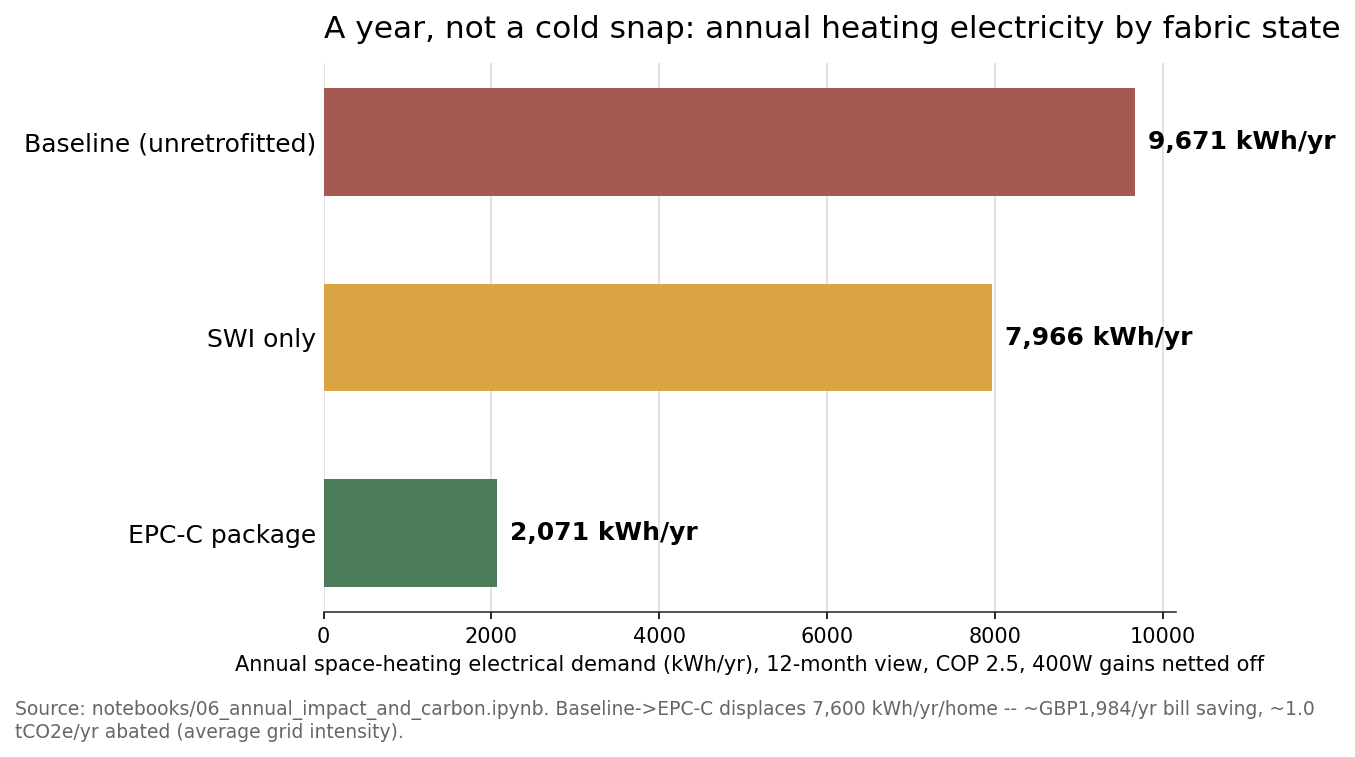

In [8]:
fig, ax = plt.subplots(figsize=(9, 5), dpi=150)

order = ["epc_c", "swi_only", "baseline"]
colors = {"baseline": "#a65852", "swi_only": "#d9a441", "epc_c": "#4c7c59"}
y_pos = range(len(order))
values = [annual_kwh[k] for k in order]

bars = ax.barh(list(y_pos), values, color=[colors[k] for k in order], height=0.55, zorder=3)
for y, k in zip(y_pos, order):
    ax.text(annual_kwh[k] + 150, y, f"{annual_kwh[k]:,.0f} kWh/yr", va="center", fontsize=12, fontweight="bold")

ax.set_yticks(list(y_pos))
ax.set_yticklabels([labels[k] for k in order], fontsize=12)
ax.set_xlabel("Annual space-heating electrical demand (kWh/yr), 12-month view, COP 2.5, 400W gains netted off")
ax.set_title("A year, not a cold snap: annual heating electricity by fabric state", fontsize=15, loc="left", pad=12)
ax.grid(axis="x", color="#dddddd", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color("#333333")
ax.tick_params(axis="y", length=0)

fig.text(
    0.01, 0.01,
    f"Source: notebooks/06_annual_impact_and_carbon.ipynb. Baseline->EPC-C displaces "
    f"{annual_kwh['baseline']-annual_kwh['epc_c']:,.0f} kWh/yr/home -- ~GBP{(annual_kwh['baseline']-annual_kwh['epc_c'])*electricity_price:,.0f}/yr bill saving, "
    f"~{(annual_kwh['baseline']-annual_kwh['epc_c'])*carbon_avg/1000:.1f} tCO2e/yr abated (average grid intensity).",
    fontsize=9, color="#666666", wrap=True,
)

fig_path = Path("../figures/annual_impact_by_envelope_state.png")
fig_path.parent.mkdir(exist_ok=True)
plt.tight_layout(rect=[0, 0.06, 1, 1])
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"Saved {fig_path}")

In [9]:
summary = pl.DataFrame({
    "envelope_state": list(annual_kwh.keys()),
    "h_w_per_k": [h_by_state[k] for k in annual_kwh],
    "annual_electrical_heating_kwh": [annual_kwh[k] for k in annual_kwh],
})

annual_comparisons_df = pl.DataFrame(annual_summary_rows)

estate_scale = pl.DataFrame({
    "scenario": ["potential_100pct_retrofit", "today_27pct_uptake"],
    "mwh_per_1000_homes": [potential_mwh, today_mwh],
    "gbp_per_1000_homes": [potential_gbp, today_gbp],
    "tco2e_avg_per_1000_homes": [potential_co2_avg_t, today_co2_avg_t],
    "tco2e_marginal_lo_per_1000_homes": [potential_co2_marg_t[0], today_co2_marg_t[0]],
    "tco2e_marginal_hi_per_1000_homes": [potential_co2_marg_t[1], today_co2_marg_t[1]],
})

output_path = Path("../data/intermediate/06_annual_impact_and_carbon.parquet")
output_path.parent.mkdir(exist_ok=True)
summary.write_parquet(output_path)

print("Per-state annual electrical heating summary:")
print(summary)
print()
print("Pairwise displaced-energy/bill/carbon summary:")
print(annual_comparisons_df)
print()
print("Estate-scale (per 1,000 homes) summary:")
print(estate_scale)
print()
print(f"Saved {output_path}")

Per-state annual electrical heating summary:
shape: (3, 3)
┌────────────────┬───────────┬───────────────────────────────┐
│ envelope_state ┆ h_w_per_k ┆ annual_electrical_heating_kwh │
│ ---            ┆ ---       ┆ ---                           │
│ str            ┆ f64       ┆ f64                           │
╞════════════════╪═══════════╪═══════════════════════════════╡
│ baseline       ┆ 272.75    ┆ 9671.08992                    │
│ swi_only       ┆ 230.75    ┆ 7966.03776                    │
│ epc_c          ┆ 85.55     ┆ 2071.428864                   │
└────────────────┴───────────┴───────────────────────────────┘

Pairwise displaced-energy/bill/carbon summary:
shape: (3, 6)
┌────────────────┬────────────────┬────────────────┬───────────────┬───────────────┬───────────────┐
│ comparison     ┆ displaced_kwh_ ┆ bill_saving_gb ┆ co2_avg_kg_pe ┆ co2_marginal_ ┆ co2_marginal_ │
│ ---            ┆ per_home       ┆ p_per_home     ┆ r_home        ┆ lo_kg_per_hom ┆ hi_kg_per_hom │
│ str    

## 8. Lifetime economics: what a negawatt costs, net

Every figure above is an annual rate. A retrofit is a one-off capital spend against a
multi-decade fabric life -- so the honest cost-effectiveness question is a lifetime one,
not an annual one. Two things follow from combining the retrofit cost (`notebooks/04`)
with this notebook's own annual bill-saving and carbon figures over a sourced fabric
lifetime (`annual_impact.lifetime_economics.fabric_life_years`, GROUNDED, 36 years --
Ofgem ECO/Green Deal "Appropriate Guarantees" convention for solid wall insulation, see
citations.md):

1. **Simple payback** -- how many years of bill savings alone repay the capital cost.
2. **Marginal abatement cost, gross AND net** -- gross treats the capital spend as a pure
   cost; net subtracts the lifetime bill savings the same spend also buys, which is the
   standard treatment in a marginal abatement cost curve (fuel-cost savings are an
   offsetting benefit, not something to ignore). Reporting only the gross figure -- as an
   earlier draft of the negawatt article did, with an unsourced 40-year lifetime -- both
   overstates the true cost AND omits a sourced assumption. Fixed here.

In [10]:
fabric_life_years = ai["lifetime_economics"]["fabric_life_years"]["value"]
retrofit_cost = cfg["retrofit_cost_gbp_to_epc_c"]["pre_1919_age_band_average"]

# Reuse the baseline->EPC-C row already computed in Section 3 above, so this section can
# never drift out of sync with Section 3's own numbers.
b2e = next(row for row in annual_summary_rows if row["comparison"] == "Baseline -> EPC-C")

bill_gbp_per_yr = b2e["bill_saving_gbp_per_home"]
co2_avg_t_per_yr = b2e["co2_avg_kg_per_home"] / 1000
co2_marg_lo_t_per_yr = b2e["co2_marginal_lo_kg_per_home"] / 1000
co2_marg_hi_t_per_yr = b2e["co2_marginal_hi_kg_per_home"] / 1000

payback_years = retrofit_cost / bill_gbp_per_yr

lifetime_bill_savings_gbp = bill_gbp_per_yr * fabric_life_years
net_position_gbp = retrofit_cost - lifetime_bill_savings_gbp  # negative = net cash saved

lifetime_co2_avg_t = co2_avg_t_per_yr * fabric_life_years
lifetime_co2_marg_lo_t = co2_marg_lo_t_per_yr * fabric_life_years
lifetime_co2_marg_hi_t = co2_marg_hi_t_per_yr * fabric_life_years

gross_avg_gbp_per_t = retrofit_cost / lifetime_co2_avg_t
gross_marg_lo_gbp_per_t = retrofit_cost / lifetime_co2_marg_hi_t  # more lifetime carbon -> lower cost
gross_marg_hi_gbp_per_t = retrofit_cost / lifetime_co2_marg_lo_t

net_avg_gbp_per_t = net_position_gbp / lifetime_co2_avg_t
net_marg_lo_gbp_per_t = net_position_gbp / lifetime_co2_marg_hi_t
net_marg_hi_gbp_per_t = net_position_gbp / lifetime_co2_marg_lo_t

print(f"Fabric life: {fabric_life_years} years (GROUNDED, Ofgem ECO/Green Deal solid-wall-insulation convention)")
print(f"Retrofit cost: GBP {retrofit_cost:,}/home")
print(f"Annual bill saving (baseline->EPC-C): GBP {bill_gbp_per_yr:,.2f}/yr")
print(f"Simple payback: {payback_years:.2f} years")
print()
print(f"Lifetime bill savings ({fabric_life_years} yr): GBP {lifetime_bill_savings_gbp:,.2f}")
print(f"Net cash position over fabric life: GBP {net_position_gbp:,.2f} "
      f"({'net SAVED' if net_position_gbp < 0 else 'net cost'}, capex minus lifetime bill savings)")
print()
print(f"Lifetime carbon abated, average basis: {lifetime_co2_avg_t:.2f} tCO2e")
print(f"Lifetime carbon abated, marginal-proxy basis: {lifetime_co2_marg_lo_t:.2f}-{lifetime_co2_marg_hi_t:.2f} tCO2e")
print()
print(f"GROSS marginal abatement cost (capex only, ignores bill savings):")
print(f"  average basis:  GBP {gross_avg_gbp_per_t:,.1f}/tCO2e")
print(f"  marginal basis: GBP {gross_marg_lo_gbp_per_t:,.1f}-{gross_marg_hi_gbp_per_t:,.1f}/tCO2e")
print()
print(f"NET marginal abatement cost (capex minus lifetime bill savings -- the standard MACC treatment):")
print(f"  average basis:  GBP {net_avg_gbp_per_t:,.1f}/tCO2e")
print(f"  marginal basis: GBP {net_marg_lo_gbp_per_t:,.1f} to {net_marg_hi_gbp_per_t:,.1f}/tCO2e")
print()
print("Negative NET figures mean the measure is cash-positive over its life even before")
print("counting any carbon value -- a standard 'no-regrets' / negative-cost abatement")
print("result, not a sign error: the retrofit pays back its own capital cost in bill")
print(f"savings alone within {payback_years:.1f} years, then continues saving money and")
print(f"abating carbon for the remaining {fabric_life_years - payback_years:.1f} years of its life for free.")


Fabric life: 36 years (GROUNDED, Ofgem ECO/Green Deal solid-wall-insulation convention)
Retrofit cost: GBP 10,728/home
Annual bill saving (baseline->EPC-C): GBP 1,984.27/yr
Simple payback: 5.41 years

Lifetime bill savings (36 yr): GBP 71,433.77
Net cash position over fabric life: GBP -60,705.77 (net SAVED, capex minus lifetime bill savings)

Lifetime carbon abated, average basis: 35.84 tCO2e
Lifetime carbon abated, marginal-proxy basis: 95.76-109.44 tCO2e

GROSS marginal abatement cost (capex only, ignores bill savings):
  average basis:  GBP 299.3/tCO2e
  marginal basis: GBP 98.0-112.0/tCO2e

NET marginal abatement cost (capex minus lifetime bill savings -- the standard MACC treatment):
  average basis:  GBP -1,693.8/tCO2e
  marginal basis: GBP -554.7 to -634.0/tCO2e

Negative NET figures mean the measure is cash-positive over its life even before
counting any carbon value -- a standard 'no-regrets' / negative-cost abatement
result, not a sign error: the retrofit pays back its own ca